# 📊 エリア × 商品カテゴリ別　売上・利益・利益率

エリアと商品カテゴリの組み合わせごとに、売上・利益・利益率をバブルチャートで表示する。
外側の淡色バブルが売上、内側の濃色バブルが利益の大きさを表す。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [ ]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import Proc01info, Cols, Items
from Lv01_03_configuration.cnfg_u_local_02_function import generate_dic_ym_to_fiscal_quarter
from Lv01_03_configuration.cnfg_p_chart import generate_chart_bubble_region_category
from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

In [5]:
# ================================================ #
# データ読み込み・加工
# ================================================ #

# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path=Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col        = Cols.order_date,
        output_col        = Cols.order_ym,
        trans_to_datetime = True
    )
)

# 集計期間の設定
fiscal_start_month = 1
start_year         = 2025
start_month        = 1
end_year           = start_year
end_month          = 12

dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year,
    start_month        = start_month,
    end_year           = end_year,
    end_month          = end_month
)
current_list_full = list(dic_current_quarter)
current_list      = current_list_full[:7]

current_df = (
    df.loc[df[Cols.order_ym].isin(current_list)]
    .copy()
    .reset_index(drop=True)
)

# 軸・色の設定
x_axis_col       = Cols.region
x_axis_item_list = Items.list_region
x_axis_display   = Items.list_region_jp

y_axis_col       = Cols.category
y_axis_item_list = Items.list_product_category
y_axis_display   = Items.list_product_category_jp
y_color_map_light = Items.light_color_map_procat()
y_color_map_dark  = Items.dark_color_map_procat()

group_col = [x_axis_col, y_axis_col]

# 全グリッドの枠を作成
df_fullgrid = pd.MultiIndex.from_product(
    [x_axis_item_list, y_axis_item_list],
    names=[x_axis_col, y_axis_col]
).to_frame(index=False)

df_fullgrid[x_axis_col] = pd.Categorical(df_fullgrid[x_axis_col], categories=list(x_axis_item_list), ordered=True)
df_fullgrid["x_cordinate"] = df_fullgrid[x_axis_col].cat.codes
df_fullgrid[y_axis_col] = pd.Categorical(df_fullgrid[y_axis_col], categories=list(y_axis_item_list), ordered=True)
df_fullgrid["y_cordinate"] = df_fullgrid[y_axis_col].cat.codes

# 売上の集計
df_sales = (
    current_df.copy()
    .groupby(group_col, as_index=False)[Cols.sales]
    .sum()
)
df_sales_full = pd.merge(df_fullgrid.copy(), df_sales, how="left", on=[x_axis_col, y_axis_col])
df_sales_full["bubble_color"] = df_sales_full[y_axis_col].astype(str).map(y_color_map_light).fillna("#000000")
df_sales_full["is_show"] = True

# 利益の集計
df_profit = (
    current_df.copy()
    .groupby(group_col, as_index=False)[Cols.profit]
    .sum()
)
df_profit_full = pd.merge(df_fullgrid.copy(), df_profit, how="left", on=[x_axis_col, y_axis_col])
df_profit_full["bubble_color"] = df_profit_full[y_axis_col].astype(str).map(y_color_map_dark).fillna("#000000")

# 利益率の計算
df_profit_full = pd.merge(
    df_profit_full,
    df_sales_full[[Cols.sales, x_axis_col, y_axis_col]].rename(columns={Cols.sales: f"{Cols.sales}_right"}),
    how="left", on=[x_axis_col, y_axis_col]
)
df_profit_full["profit_abs"]   = df_profit_full[Cols.profit].abs()
df_profit_full["profit_ratio"] = (df_profit_full["profit_abs"] / df_profit_full[f"{Cols.sales}_right"]).round(3)
df_profit_full["pos_neg"]      = np.where(df_profit_full[Cols.profit] >= 0, "▲", "▼")
df_profit_full["font_color"]   = np.where(df_profit_full[Cols.profit] >= 0, "#000000", "#B22222")


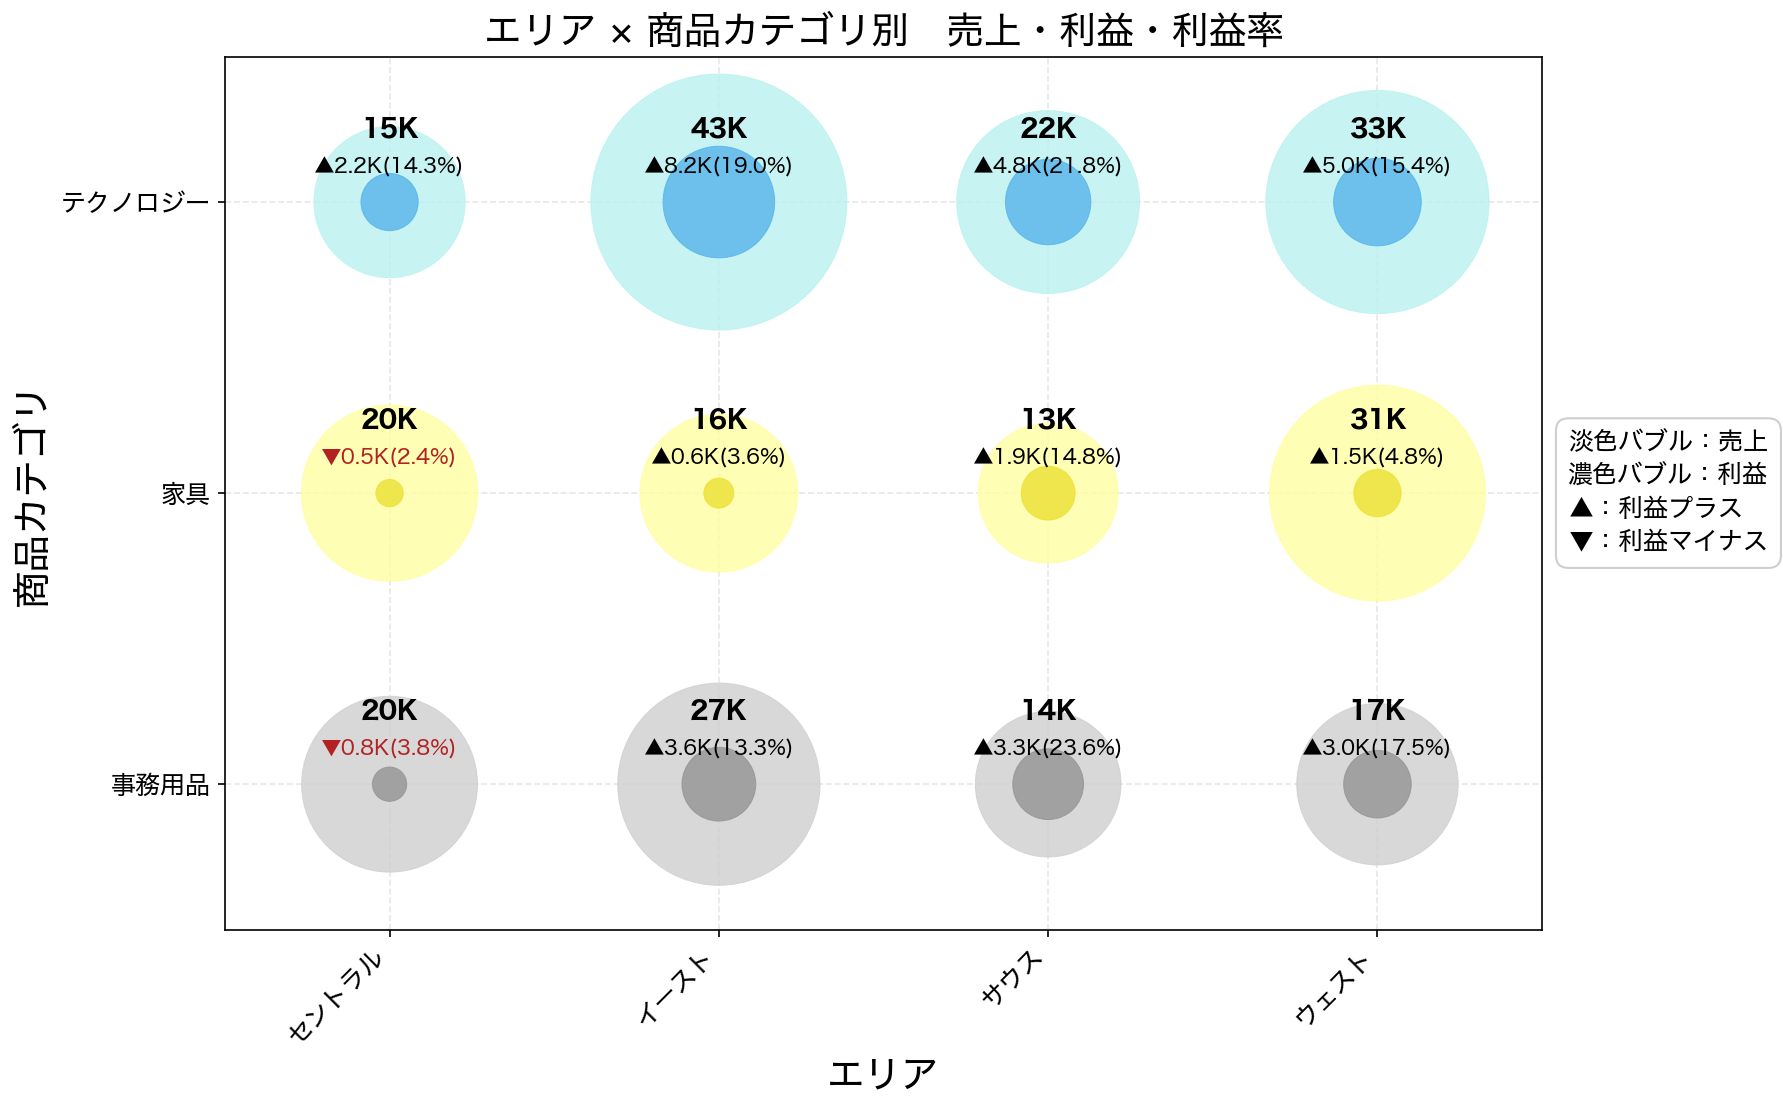

In [6]:
# ================================================ #
# チャート生成
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=150)

generate_chart_bubble_region_category(
    df_sales_full    = df_sales_full,
    df_profit_full   = df_profit_full,
    ax               = ax,
    fig              = fig,
    x_axis_item_list = x_axis_item_list,
    x_axis_display   = x_axis_display,
    y_axis_item_list = y_axis_item_list,
    y_axis_display   = y_axis_display,
    title            = "エリア × 商品カテゴリ別　売上・利益・利益率",
)

plt.tight_layout()
plt.show()